In [1]:
import numpy as np
import pandas as pd

In [2]:
covid_death_df = pd.read_csv('time_series_covid19_deaths_global.csv')

In [3]:
covid_confirmed_df = pd.read_csv('time_series_covid19_confirmed_global.csv')

In [4]:
covid_death_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [5]:
covid_confirmed_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


### MultiIndexing (Hierarchical Indexing)

It is used to work with **multiple levels of indexing** in a DataFrame or Series, allowing more complex data representation and selection.

---

#### Syntax

        df.set_index(['col1', 'col2'])

| Parameter | Description                              | Default | Possible Values              |
|-----------|------------------------------------------|---------|-----------------------------|
| keys      | Columns to create MultiIndex             | —       | list of column labels       |
| level     | Level to access/select                   | None    | int, level name             |
| names     | Names of index levels                    | None    | list                        |

---

#### Key Points

- Allows **hierarchical (multi-level) indexing**  
- Useful for representing **higher-dimensional data**  
- Enables advanced slicing and grouping  
- Commonly created using:
  - `.set_index()`  
  - `.groupby()`  
  - `.pivot_table()`  

---

#### Common Operations

| Operation                  | Description                          |
|---------------------------|--------------------------------------|
| `df.loc[('A', 1)]`        | Access specific multi-level row      |
| `df.xs('A', level=0)`     | Cross-section by level               |
| `df.unstack()`            | Convert index level to columns       |
| `df.stack()`              | Convert columns to index level       |
| `df.reset_index()`        | Flatten MultiIndex                   |


### MultiIndex Object (Pandas)

It is the **object used to represent hierarchical (multi-level) indexing** in Pandas.

---

#### Syntax

        pd.MultiIndex(levels=None, codes=None, names=None)

| Parameter | Description                              | Default | Possible Values              |
|-----------|------------------------------------------|---------|-----------------------------|
| levels    | Unique labels for each level             | None    | list of lists               |
| codes     | Integer positions for each label         | None    | list of lists               |
| names     | Names of each index level                | None    | list                        |

---

#### Key Points

- Core structure behind **MultiIndex DataFrame/Series**  
- Each level represents a **dimension of indexing**  
- Can be created using:
  - `from_arrays()`  
  - `from_tuples()`  
  - `from_product()`  

---

#### Common Constructors

| Method                     | Description                          |
|---------------------------|--------------------------------------|
| `from_arrays()`           | Create from multiple arrays          |
| `from_tuples()`           | Create from list of tuples           |
| `from_product()`          | Create Cartesian product index       |



In [6]:
multi_index = pd.MultiIndex.from_product([['cse', 'ece'], [2021, 2022, 2023, 2024]])
multi_index

MultiIndex([('cse', 2021),
            ('cse', 2022),
            ('cse', 2023),
            ('cse', 2024),
            ('ece', 2021),
            ('ece', 2022),
            ('ece', 2023),
            ('ece', 2024)],
           )

In [7]:
dummy = pd.Series(data=[11,12,13,14,15,16,17,19], index=multi_index)

In [8]:
dummy

cse  2021    11
     2022    12
     2023    13
     2024    14
ece  2021    15
     2022    16
     2023    17
     2024    19
dtype: int64

In [9]:
# fetching 16 from the series

dummy[('ece', 2022)]

np.int64(16)

In [10]:
# fetching all rows where cse is present

dummy.loc['cse']

2021    11
2022    12
2023    13
2024    14
dtype: int64

In [11]:
dummy.shape

(8,)

In [12]:
dummy.ndim

1

### .unstack() 

It is used to **pivot a level of the index into columns**, converting row index levels into column labels.

- **Syntax**

        df.unstack(level=-1)

| Parameter   | Description                                      | Default | Possible Values              |
|-------------|--------------------------------------------------|---------|-----------------------------|
| level       | Level of index to unstack                        | -1      | int, level name             |
| fill_value  | Value to replace missing values                  | None    | scalar                      |
| sort        | Sort the resulting index                         | True    | True, False                 |

---

#### Key Points

- Converts **row index → columns**  
- Works mainly with **MultiIndex**  
- Opposite of `.stack()`  
- Missing combinations result in **NaN** (unless filled)

In [13]:
dummy_df = dummy.unstack()

In [14]:
dummy_df

,2021,2022,2023,2024
cse,11,12,13,14
ece,15,16,17,19


### .stack() 

It is used to **pivot columns into index**, converting column labels into a new inner level of the row index.

- **Syntax**

        df.stack(level=-1)

| Parameter   | Description                                      | Default | Possible Values              |
|-------------|--------------------------------------------------|---------|-----------------------------|
| level       | Level of columns to stack                        | -1      | int, level name             |
| dropna      | Drop rows with missing values after stacking     | True    | True, False                 |
| sort        | Sort the resulting index                         | True    | True, False                 |

---

#### Key Points

- Converts **columns → row index**  
- Opposite of `.unstack()`  
- Creates a **MultiIndex** in rows  
- Drops NaN values by default (can be controlled)

In [15]:
dummy_series = dummy_df.stack()

In [16]:
dummy_series

cse  2021    11
     2022    12
     2023    13
     2024    14
ece  2021    15
     2022    16
     2023    17
     2024    19
dtype: int64

In [17]:
dummy_df1 = pd.DataFrame(data={
    'avg_package':[6,7,8,9,10,11,12,13],
    'Placed_student':[10,20,30,40,50,40,30,20]
}, index=multi_index)

In [18]:
dummy_df1

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [19]:
dummy_df1.unstack()

avg_package                Placed_student               
           2021 2022 2023 2024           2021 2022 2023 2024
cse           6    7    8    9             10   20   30   40
ece          10   11   12   13             50   40   30   20

In [20]:
dummy_df1.unstack().unstack()

avg_package     2021  cse     6
                      ece    10
                2022  cse     7
                      ece    11
                2023  cse     8
                      ece    12
                2024  cse     9
                      ece    13
Placed_student  2021  cse    10
                      ece    50
                2022  cse    20
                      ece    40
                2023  cse    30
                      ece    30
                2024  cse    40
                      ece    20
dtype: int64

In [21]:
dummy_df1

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [22]:
dummy_df1.stack()

cse  2021  avg_package        6
           Placed_student    10
     2022  avg_package        7
           Placed_student    20
     2023  avg_package        8
           Placed_student    30
     2024  avg_package        9
           Placed_student    40
ece  2021  avg_package       10
           Placed_student    50
     2022  avg_package       11
           Placed_student    40
     2023  avg_package       12
           Placed_student    30
     2024  avg_package       13
           Placed_student    20
dtype: int64

In [23]:
#basic functions

dummy_df1.head()

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50

In [24]:
dummy_df1.tail()

avg_package  Placed_student
cse 2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [25]:
dummy_df1.shape

(8, 2)

In [26]:
dummy_df1.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2021)) to ('ece', np.int64(2024))
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   avg_package     8 non-null      int64
 1   Placed_student  8 non-null      int64
dtypes: int64(2)
memory usage: 804.0+ bytes


In [27]:
dummy_df1

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [28]:
#extracting single row

dummy_df1.iloc[0,:]

avg_package        6
Placed_student    10
Name: (cse, 2021), dtype: int64

In [29]:
dummy_df1.loc[('cse', 2021)]

avg_package        6
Placed_student    10
Name: (cse, 2021), dtype: int64

In [30]:
#extracting single column

dummy_df1.iloc[:,0]

cse  2021     6
     2022     7
     2023     8
     2024     9
ece  2021    10
     2022    11
     2023    12
     2024    13
Name: avg_package, dtype: int64

In [31]:
dummy_df1.loc[:,'Placed_student']

cse  2021    10
     2022    20
     2023    30
     2024    40
ece  2021    50
     2022    40
     2023    30
     2024    20
Name: Placed_student, dtype: int64

In [32]:
#extracting 2nd and 3rd row of 2nd column

dummy_df1.iloc[1:3,1]

cse  2022    20
     2023    30
Name: Placed_student, dtype: int64

In [33]:
dummy_df1

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [34]:
#sort the level 0 index descending order and level 1 index in ascending order

dummy_df1.sort_index(level=[0,1],ascending=[False,True])

avg_package  Placed_student
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40

### .transpose() 

It is used to **swap rows and columns** of a DataFrame or Series.

- **Syntax**

        df.transpose()

| Parameter | Description                         | Default | Possible Values |
|-----------|-------------------------------------|---------|-----------------|
| copy      | Return a copy of the data           | False   | True, False     |

---

#### Key Points

- Converts **rows → columns** and **columns → rows**  
- Shortcut: `df.T`  
- Useful for **reshaping data**  


In [35]:
dummy_df1.transpose()

cse                 ece               
               2021 2022 2023 2024 2021 2022 2023 2024
avg_package       6    7    8    9   10   11   12   13
Placed_student   10   20   30   40   50   40   30   20

In [36]:
dummy_df1.T

cse                 ece               
               2021 2022 2023 2024 2021 2022 2023 2024
avg_package       6    7    8    9   10   11   12   13
Placed_student   10   20   30   40   50   40   30   20

### .swaplevel() 

It is used to **swap two levels of a MultiIndex** in rows or columns.

- **Syntax**

        df.swaplevel(i=-2, j=-1, axis=0)

| Parameter | Description                              | Default | Possible Values              |
|-----------|------------------------------------------|---------|-----------------------------|
| i         | First level to swap                      | -2      | int, level name             |
| j         | Second level to swap                     | -1      | int, level name             |
| axis      | Axis on which to swap levels             | 0       | 0 (index), 1 (columns)      |

---

#### Key Points

- Works only with **MultiIndex**  
- Does not sort the index automatically  
- Often used with `.sort_index()` after swapping  

In [37]:
dummy_df1

avg_package  Placed_student
cse 2021            6              10
    2022            7              20
    2023            8              30
    2024            9              40
ece 2021           10              50
    2022           11              40
    2023           12              30
    2024           13              20

In [38]:
dummy_df1.swaplevel()

,,avg_package,Placed_student
2021,cse,6,10
2022,cse,7,20
2023,cse,8,30
2024,cse,9,40
2021,ece,10,50
2022,ece,11,40
2023,ece,12,30
2024,ece,13,20




## Long Format (Tidy Data)

In long format, each row represents **one observation per variable**.

- More rows, fewer columns  
- Suitable for analysis, grouping, and visualization  

---

### Example (Long Format)

| ID | Variable | Value |
|----|----------|-------|
| 1  | Height   | 170   |
| 1  | Weight   | 65    |
| 2  | Height   | 180   |
| 2  | Weight   | 75    |

---

### Key Points

- Each row = one measurement  
- Easier for `.groupby()`, `.agg()`  
- Preferred for statistical analysis  

---

## Wide Format

In wide format, each row represents **one entity with multiple variables as columns**.

- Fewer rows, more columns  
- Suitable for reporting and readability  

---

### Example (Wide Format)

| ID | Height | Weight |
|----|--------|--------|
| 1  | 170    | 65     |
| 2  | 180    | 75     |

---

### Key Points

- Each row = one entity  
- Easier for human reading  
- Common in spreadsheets  

---

## Conversion in Pandas

| Operation     | Method        |
|---------------|--------------|
| Wide → Long   | `pd.melt()`  |
| Long → Wide   | `pivot()` / `pivot_table()` |


### .melt() 

It is used to transform data from **wide format to long format** (unpivoting).


#### Syntax
    pd.melt(frame, id_vars=None, value_vars=None)



| Parameter   | Description                                              | Default | Possible Values                          |
|-------------|----------------------------------------------------------|---------|------------------------------------------|
| frame       | DataFrame to reshape                                     | —       | DataFrame                                |
| id_vars     | Columns to keep as identifiers                           | None    | column label, list                       |
| value_vars  | Columns to unpivot                                       | None    | column label, list                       |
| var_name    | Name for the variable column                             | None    | str                                      |
| value_name  | Name for the value column                                | 'value' | str                                      |
| col_level   | Level to use (for MultiIndex columns)                    | None    | int                                      |
| ignore_index| Reset index in result                                    | True    | True, False                              |


#### Key Points

- Converts **wide → long format**  
- Creates two columns:
  - variable (column names)
  - value (data)  
- Useful for **tidy data and analysis**  

In [39]:
dummy_df = pd.DataFrame({
    'branch':['cse','ece','ee'],
    'batch':[2020,2021,2022],
    'number_of_student':[100,150,200],
    'placed_student_count':[10,20,30]
    })

In [40]:
dummy_df

,branch,batch,number_of_student,placed_student_count
0,cse,2020,100,10
1,ece,2021,150,20
2,ee,2022,200,30


In [41]:
dummy_df.melt() # doesn't give any meaningful output

,variable,value
0,branch,cse
1,branch,ece
2,branch,ee
3,batch,2020
4,batch,2021
5,batch,2022
6,number_of_student,100
7,number_of_student,150
8,number_of_student,200
9,placed_student_count,10


In [42]:
dummy_df.melt(id_vars=['branch', 'batch'], var_name='detail', value_name='count')

,branch,batch,detail,count
0,cse,2020,number_of_student,100
1,ece,2021,number_of_student,150
2,ee,2022,number_of_student,200
3,cse,2020,placed_student_count,10
4,ece,2021,placed_student_count,20
5,ee,2022,placed_student_count,30


### Generate a table where there are 4 columns only, i.e., Country_name, date, confirmed_case, death_count in the covid dataset

In [43]:
covid_confirmed_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [44]:
covid_death_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [45]:
covid_death_df.drop(labels=['Province/State', 'Lat', 'Long'], axis = 1, inplace = True)

In [46]:
covid_confirmed_df.drop(labels=['Province/State', 'Lat', 'Long'], axis = 1, inplace = True)

In [47]:
covid_confirmed_df.head()

,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,Afghanistan,0,0,0,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,Albania,0,0,0,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,Algeria,0,0,0,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,Andorra,0,0,0,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,Angola,0,0,0,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [48]:
covid_death_df.head()

,Country/Region,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,Afghanistan,0,0,0,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,Albania,0,0,0,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,Algeria,0,0,0,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,Andorra,0,0,0,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,Angola,0,0,0,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [49]:
covid_death_long = covid_death_df.melt(id_vars='Country/Region', var_name='Date', value_name='Death_count')

In [50]:
covid_death_long.head(5)

,Country/Region,Date,Death_count
0,Afghanistan,1/22/20,0
1,Albania,1/22/20,0
2,Algeria,1/22/20,0
3,Andorra,1/22/20,0
4,Angola,1/22/20,0


In [51]:
covid_confirmed_long = covid_confirmed_df.melt(id_vars='Country/Region', var_name='Date', value_name='Confirmed_count')

In [52]:
covid_confirmed_long.head()

,Country/Region,Date,Confirmed_count
0,Afghanistan,1/22/20,0
1,Albania,1/22/20,0
2,Algeria,1/22/20,0
3,Andorra,1/22/20,0
4,Angola,1/22/20,0


In [57]:
pd.merge(covid_confirmed_long, covid_death_long, how='inner', on=['Country/Region', 'Date'])

,Country/Region,Date,Confirmed_count,Death_count
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
2241232,West Bank and Gaza,1/2/23,703228,5708
2241233,Winter Olympics 2022,1/2/23,535,0
2241234,Yemen,1/2/23,11945,2159
2241235,Zambia,1/2/23,334661,4024


### `.pivot_table()`  

It is used to **summarize and aggregate data** by grouping values based on rows and columns.


#### Syntax
    pd.pivot_table(data, values=None, index=None, columns=None, aggfunc='mean')


| Parameter     | Description                                              | Default  | Possible Values                          |
|---------------|----------------------------------------------------------|----------|------------------------------------------|
| data          | DataFrame to operate on                                  | —        | DataFrame                                |
| values        | Column(s) to aggregate                                   | None     | column label, list                       |
| index         | Columns to group by (rows)                               | None     | column label, list                       |
| columns       | Columns to group by (columns)                            | None     | column label, list                       |
| aggfunc       | Aggregation function                                     | 'mean'   | mean, sum, count, min, max, list, etc.   |
| fill_value    | Value to replace missing values                          | None     | scalar                                   |
| margins       | Adds total row/column                                    | False    | True, False                              |
| margins_name  | Name of total row/column                                 | 'All'    | str                                      |
| dropna        | Exclude columns with all NaN                             | True     | True, False                              |


#### Key Points

- Performs **grouping + aggregation in one step**  
- Similar to **Excel pivot table**  
- Supports **multi-level indexing**  
- Handles **missing values using `fill_value`**  
- Can apply **multiple aggregation functions**  

In [5]:
df = pd.read_csv('tips.csv')

In [6]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Find the average billing cost genderwise

In [8]:
df.groupby(by=['sex'], dropna=False)['total_bill'].mean()

sex
Female    18.056897
Male      20.744076
Name: total_bill, dtype: float64

### Find the average billing cost genderwise and smokerwise

In [9]:
df.groupby(by=['sex','smoker'], dropna=False)['total_bill'].mean()

sex     smoker
Female  No        18.105185
        Yes       17.977879
Male    No        19.791237
        Yes       22.284500
Name: total_bill, dtype: float64

In [10]:
df.groupby(by=['sex','smoker'], dropna=False)['total_bill'].mean().unstack()

smoker,No,Yes
sex,,
Female,18.105185,17.977879
Male,19.791237,22.284500


In [12]:
pd.pivot_table(data=df, values='total_bill', index=['sex','smoker'], aggfunc='mean')

total_bill
sex    smoker            
Female No       18.105185
       Yes      17.977879
Male   No       19.791237
       Yes      22.284500

In [13]:
df.pivot_table(values='total_bill', index='sex', columns='smoker', aggfunc='mean')

smoker,No,Yes
sex,,
Female,18.105185,17.977879
Male,19.791237,22.284500


In [14]:
df.pivot_table(values=['total_bill', 'tip'], index='sex', columns='smoker', aggfunc={'tip':'max', 'total_bill':'mean'}, margins=True)

tip             total_bill                      
smoker   No   Yes   All         No        Yes        All
sex                                                     
Female  5.2   6.5   6.5  18.105185  17.977879  18.056897
Male    9.0  10.0  10.0  19.791237  22.284500  20.744076
All     9.0  10.0  10.0  19.188278  20.756344  19.785943

In [15]:
df1 = pd.read_csv('expense_data.csv')
df1.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [16]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [19]:
df1['Date']=pd.to_datetime(df1['Date'])

In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [22]:
df1['Month'] = df1['Date'].dt.month_name()

In [ ]:
df1['Year'] = df1['Date'].dt.

In [23]:
df1

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,November


In [24]:
df1.pivot_table(values='INR', index='Category', columns='Currency', aggfunc='sum')

Currency,INR,USD
Category,,
Allowance,14000.00,NaN
Apparel,3388.00,NaN
Beauty,196.00,NaN
Education,1400.00,NaN
Food,23381.76,1120.72
Gift,115.00,NaN
Household,12188.00,NaN
Other,37868.00,NaN
Petty cash,3.00,NaN


<Axes: xlabel='Category'>

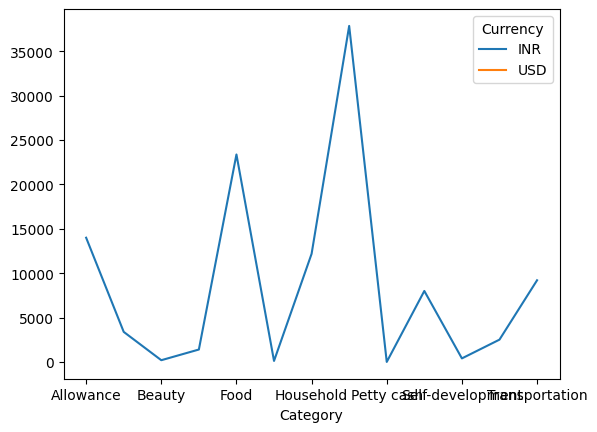

In [25]:
df1.pivot_table(values='INR', index='Category', columns='Currency', aggfunc='sum').plot()

In [30]:
df1.pivot_table(values='INR', index='Month', columns='Income/Expense', aggfunc='sum')

Income/Expense,Expense,Income
Month,,
December,16334.44,12310.0
February,17864.65,18200.0
January,20679.51,19641.0
March,525.00,600.0
November,3620.40,4003.0


<Axes: xlabel='Month'>

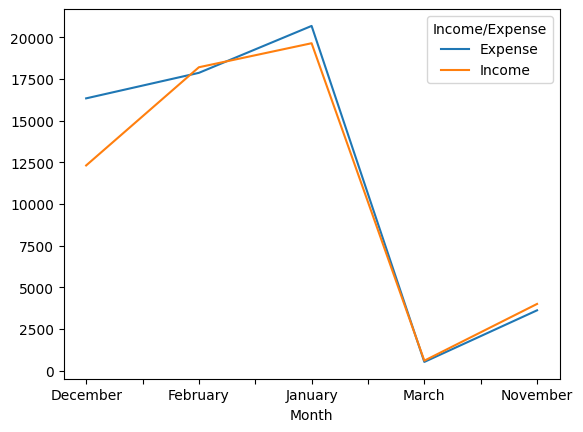

In [29]:
df1.pivot_table(values='INR', index='Month', columns='Income/Expense', aggfunc='sum').plot()